<a href="https://colab.research.google.com/github/kr7/dskim1600/blob/main/Entscheidungsbaum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entscheidungsbäume

Wir importieren die nötigen Softwarebibliotheken

In [ ]:
import numpy as np
import pydot

from six import StringIO
from sklearn.tree import export_graphviz
from IPython.display import Image
from sklearn.tree import DecisionTreeClassifier

Wir werden die Daten mit der Softwarebibliothek <i>ucimlrepo</i> laden, by Default steht das in Google Colab nicht zur Verfügung, deswegen installieren wir diese Softwarebibliothek auf die virtuelle Maschine, auf der unser Notebook läuft. (Diese Bibliothek wird dadurch auf Ihrem Rechner nicht installiert.)

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=350)
X = np.array(dataset.data.features) # Die "eigentlichen" Instanzen
y = np.array(dataset.data.targets) # Die Klassenzugehörigkeit (class labels) von den Instanzen
y = np.reshape( y, (len(y)) )

Wir teilen die Daten in Trainingsdaten und Testdaten auf:

In [ ]:
test_indices = np.array(range(int(len(X)/5)))*5
train_indices = [i for i in range(len(X)) if i not in test_indices]

X_train = X[train_indices]
X_test  = X[test_indices]
y_train = y[train_indices]
y_test  = y[test_indices]

In [ ]:
model = DecisionTreeClassifier(max_depth = 2, min_samples_leaf = 100)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=100)

Die Genauigkeit des Modells auf den Testdaten:

In [ ]:
pred = model.predict(X_test)
np.sum(pred==y_test)/len(y_test)

np.float64(0.8121666666666667)

Zunächst wird die Genauigkeit auf den Trainingsdaten berechnet.<br><font color="red"> Das ist keine zuverlässige Schätzung der Genauigkeit auf neuen Daten, aber man sieht dadurch ob das Modell unter Overfitting "leidet" oder nicht.</font>

In [ ]:
pred = model.predict(X_train)
np.sum(pred==y_train)/len(y_train)

np.float64(0.822125)

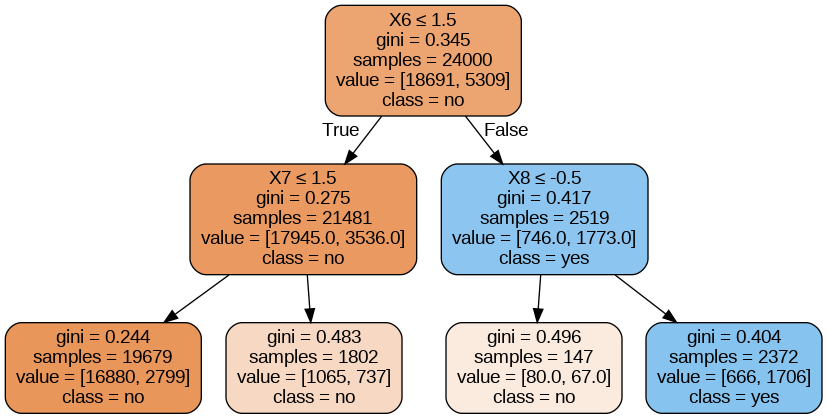

In [ ]:
dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                class_names = ['no', 'yes'],
                filled=True, rounded=True,
                special_characters=True,
                feature_names=list(dataset.data.features))
graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())

**Aufgaben**

1. Basierend auf die gerechneten Genauigkeitswerten auf den Test- und Trainingsdaten, was ist Ihre Einschätzung: ist dieser Entscheidungsbaum vom Overfitting betroffen oder nicht?
2. Lesen Sie die Dokumentation des Datensatzes (https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) und beschreiben Sie in natürlicher Sprache, wann dieser Entscheidungsbaum einen Kunden als kreditwürdig einstuft!
3. Hat man im Datensatz Information über das Geschlecht des Kunden? Hängt die Entscheidung des Entscheidungsbaumes vom Geschlecht ab?
4. Modifizieren Sie den Code, damit der Entscheidungsbaum eine Tiefe von 3 hat. Trainieren Sie das neue Model und zeigen Sie den neuen Baum an!
5. Implementieren Sie den fertigen Entscheidungsbaum als eine Funktion in Python!
6. Warum ist es wichtig die Daten in Trainings- und Testdaten zu teilen? Modifizieren Sie den Code, damit die Daten anders geteilt werden, als in der aktuellen Version, und trainieren Sie das neue Modell und zeigen Sie den neuen Baum an! Ist der neue Baum anders als der Alte?
7. Sie sollten den Code so anpassen, dass ein Entscheidungsbaum trainiert wird, um Bankrott von polnischen Unternehmen vorherzusagen. Der zugehörige Datensatz befindet sich hier: https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data
Die ID von diesem Datensatz ist: 365. (Das können Sie beim Laden der Daten benutzen.)
8. Suchen Sie nach fortgeschrittenen Darstellungsmöglichkeiten (zB. hier: https://mljar.com/blog/visualize-decision-tree/ ). Zeigen Sie Ihren Entscheidungsbaum mit einer alternativen Darstellungtechnik an!